In [1]:
import datetime as dt
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
#dataframe = pd.read_csv('data_sensorOutdor_07_12.csv')
#dataframe = pd.read_csv('data_sensorOutdor_18.csv')
#df = dataframe.copy()
#print(df)

dataPengukuran = pd.read_excel('Data_Suhu_Kelembapan.xlsx')
dataPengukuran.to_csv('Data_Suhu_Kelembapan.csv', index=None, header=True)
dfSensor = pd.DataFrame(pd.read_csv('Data_Suhu_Kelembapan.csv'))

#dataPengukuran = pd.read_excel('Data_Pengukuran_182.xlsx')
#dataPengukuran.to_csv('Data_Pengukuran_182.csv', index=None, header=True)
#dfSensor = pd.DataFrame(pd.read_csv('Data_Pengukuran_182.csv'))
df = dfSensor.copy()
print(dfSensor)

    Suhu  Kelembapan  s_suhu  s_kelem
0   26.1          43    26.9     69.4
1   27.7          41    26.9     69.9
2   28.5          37    26.9     70.0
3   31.1          32    27.3     70.2
4   34.0          29    29.0     66.8
5   38.8          27    34.9     52.8
6   41.8          25    38.7     48.8
7   44.6          25    42.8     48.6
8   46.3          23    46.8     48.4
9   47.8          23    49.1     22.9
10  49.7          22    52.2     22.9
11  50.8          22    55.5     21.8
12  51.8          20    56.1     21.1


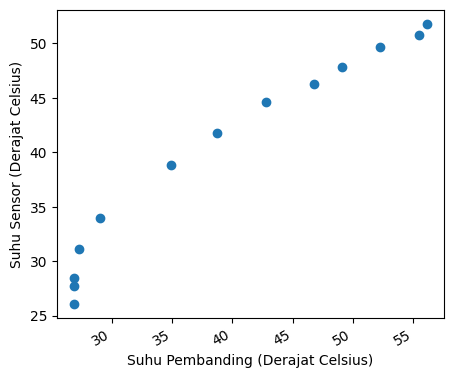

In [3]:
from scipy import stats
y = dataPengukuran['Suhu']
x = df['s_suhu']

#y = dataPengukuran['Suhu']
#x = df['Suhu']

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)

plt.xlabel("Suhu Pembanding (Derajat Celsius)")
plt.ylabel("Suhu Sensor (Derajat Celsius)")
plt.show() 

Pesamaan Regresi:  0.7959479986131941*X + 8.507621685505388


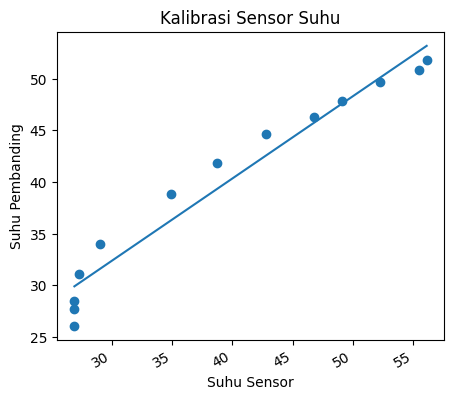

In [4]:
slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Suhu Pembanding")
plt.xlabel("Suhu Sensor")
plt.title("Kalibrasi Sensor Suhu")
plt.plot(x, mymodel)
plt.show() 

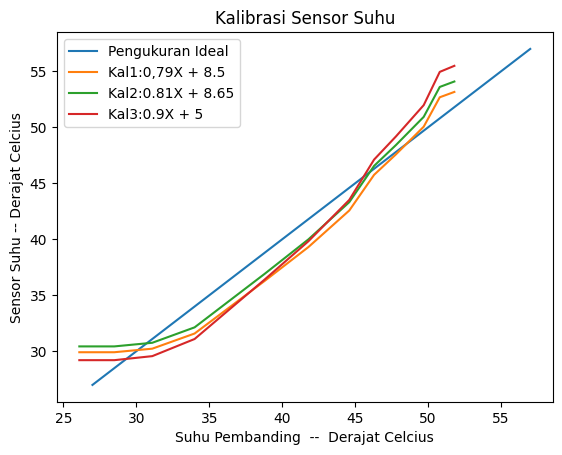

In [5]:
dtPengukuranSuhu = dataPengukuran['Suhu']
x = df['s_suhu']

xIdeal = np.arange(27, 59, 2.5)
yIdeal = np.arange(27,59,2.5)
plt.plot(xIdeal,yIdeal)

kal = 0.7959479986131941*x + 8.507621685505388
plt.plot(dtPengukuranSuhu,kal)

kal2 = 0.81*x + 8.65
plt.plot(dtPengukuranSuhu,kal2)

kal3 = 0.9*x + 5
plt.plot(dtPengukuranSuhu,kal3)

plt.xlabel("Suhu Pembanding  --  Derajat Celcius")
plt.ylabel("Sensor Suhu -- Derajat Celcius")
plt.title("Kalibrasi Sensor Suhu")
plt.legend(["Pengukuran Ideal","Kal1:0,79X + 8.5","Kal2:0.81X + 8.65","Kal3:0.9X + 5"])
plt.show() 

In [8]:
print(kal)
print(x)
dataSensor = np.array(x)
sensorPembanding = np.array(kal)

# Menghitung nilai error absolut
absolute_error = np.abs(dataSensor - sensorPembanding)

# Menghitung Mean Absolute Error (MAE)
mae = np.mean(absolute_error)

print("Mean Absolute Error (MAE):", mae)

0     29.918623
1     29.918623
2     29.918623
3     30.237002
4     31.590114
5     36.286207
6     39.310809
7     42.574196
8     45.757988
9     47.588668
10    50.056107
11    52.682736
12    53.160304
Name: s_suhu, dtype: float64
0     26.9
1     26.9
2     26.9
3     27.3
4     29.0
5     34.9
6     38.7
7     42.8
8     46.8
9     49.1
10    52.2
11    55.5
12    56.1
Name: s_suhu, dtype: float64
Mean Absolute Error (MAE): 2.0969231240732977


    KelembapanDHT  SuhuDHT  KelembapanAlat  Suhu   DHT  alat
0             NaN      NaN             NaN   NaN  78.8    65
1             NaN      NaN             NaN   NaN  78.2    64
2             NaN      NaN             NaN   NaN  77.3    63
3             NaN      NaN             NaN   NaN  76.1    61
4            72.0     28.9            65.0  30.9  75.0    60
5            71.5     28.8            64.0  29.9  74.0    59
6            71.3     28.9            63.0  30.1  73.0    58
7            71.0     28.8            64.0  31.0  71.2    57
8            71.0     29.0            62.0  30.0  70.9    56
9            71.0     29.1            61.0  29.5  69.8    55
10           70.5     29.1            61.0  29.4  68.3    53
11           70.0     28.7            64.0  31.3  67.0    50
12           70.0     29.0            62.0  29.7  66.0    46
13           69.9     29.2            61.0  29.3  65.0    44
14           69.0     29.1            62.0  29.7  64.7    43
15           68.0     28

C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\internals\blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


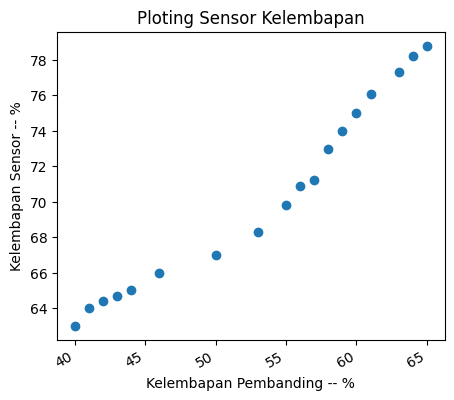

In [13]:
dataPengukuran = pd.read_excel('Sensor_Temperature_New.xlsx')
dataPengukuran.to_csv('Sensor_Temperature_New.csv', index=None, header=True)
dfSensor = pd.DataFrame(pd.read_csv('Sensor_Temperature_New.csv'))

#dataPengukuran = pd.read_excel('Data_Pengukuran_182.xlsx')
#dataPengukuran.to_csv('Data_Pengukuran_182.csv', index=None, header=True)
#dfSensor = pd.DataFrame(pd.read_csv('Data_Pengukuran_182.csv'))
df = dfSensor.copy()
print(dfSensor)


x = dataPengukuran['alat']
y = df['DHT']

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Kelembapan Pembanding -- %")
plt.ylabel("Kelembapan Sensor -- %")
plt.title("Ploting Sensor Kelembapan")
plt.show() 

C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\internals\blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


    KelembapanDHT  SuhuDHT  KelembapanAlat  Suhu   DHT  alat  \
0             NaN      NaN             NaN   NaN  78.8    65   
1             NaN      NaN             NaN   NaN  78.2    64   
2             NaN      NaN             NaN   NaN  77.3    63   
3             NaN      NaN             NaN   NaN  76.1    61   
4            72.0     28.9            65.0  30.9  75.0    60   
5            71.5     28.8            64.0  29.9  74.0    59   
6            71.3     28.9            63.0  30.1  73.0    58   
7            71.0     28.8            64.0  31.0  71.2    57   
8            71.0     29.0            62.0  30.0  70.9    56   
9            71.0     29.1            61.0  29.5  69.8    55   
10           70.5     29.1            61.0  29.4  68.3    53   
11           70.0     28.7            64.0  31.3  67.0    50   
12           70.0     29.0            62.0  29.7  66.0    46   
13           69.9     29.2            61.0  29.3  65.0    44   
14           69.0     29.1            62

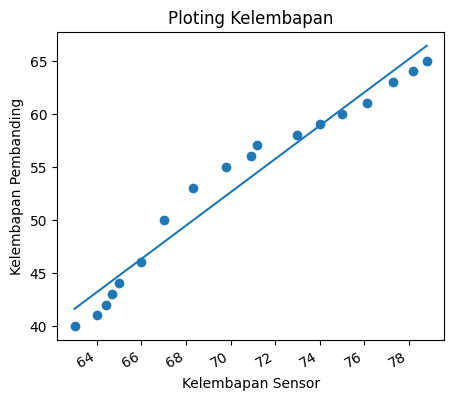

In [2]:
dataPengukuran = pd.read_excel('Sensor_Temperature_New.xlsx')
dataPengukuran.to_csv('Sensor_Temperature_New.csv', index=None, header=True)
dfSensor = pd.DataFrame(pd.read_csv('Sensor_Temperature_New.csv'))

#dataPengukuran = pd.read_excel('Data_Pengukuran_182.xlsx')
#dataPengukuran.to_csv('Data_Pengukuran_182.csv', index=None, header=True)
#dfSensor = pd.DataFrame(pd.read_csv('Data_Pengukuran_182.csv'))
df = dfSensor.copy()
print(dfSensor)


y = dataPengukuran['alat']
x = df['DHT']
slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Kelembapan Pembanding")
plt.xlabel("Kelembapan Sensor")
plt.title("Ploting Kelembapan")
plt.plot(x, mymodel)
plt.show() 

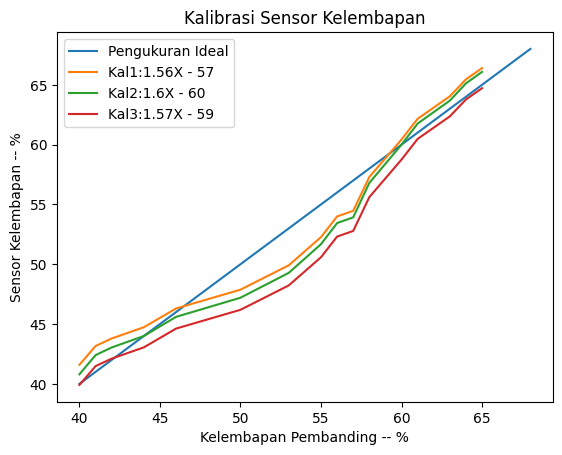

In [3]:
dtPengukuranKelembapan = dataPengukuran['alat']
x = df['DHT']

xIdeal = np.arange(40, 70, 2)
yIdeal = np.arange(40,70,2)
plt.plot(xIdeal,yIdeal)

kal = 1.5698901941903016*x + -57.30999494338081
plt.plot(dtPengukuranKelembapan,kal)

kal2 = 1.6*x + -60
plt.plot(dtPengukuranKelembapan,kal2)

kal3 = 1.57*x + -59
plt.plot(dtPengukuranKelembapan,kal3)

plt.xlabel("Kelembapan Pembanding -- %")
plt.ylabel("Sensor Kelembapan -- %")
plt.title("Kalibrasi Sensor Kelembapan")
plt.legend(["Pengukuran Ideal", "Kal1:1.56X - 57", "Kal2:1.6X - 60", "Kal3:1.57X - 59"])
plt.show() 

In [4]:
x = dataPengukuran['alat']
print(kal)
print(x)
dataSensor = np.array(x)
sensorPembanding = np.array(kal)

# Menghitung nilai error absolut
absolute_error = np.abs(dataSensor - sensorPembanding)

# Menghitung Mean Absolute Error (MAE)
mae = np.mean(absolute_error)

print("Mean Absolute Error (MAE):", mae)

0     66.397352
1     65.455418
2     64.042517
3     62.158649
4     60.431770
5     58.861879
6     57.291989
7     54.466187
8     53.995220
9     52.268341
10    49.913505
11    47.872648
12    46.302758
13    44.732868
14    44.261901
15    43.790934
16    43.162977
17    41.593087
Name: DHT, dtype: float64
0     65
1     64
2     63
3     61
4     60
5     59
6     58
7     57
8     56
9     55
10    53
11    50
12    46
13    44
14    43
15    42
16    41
17    40
Name: alat, dtype: int64
Mean Absolute Error (MAE): 1.4811367372020952


# Data Sensor CO dan CO2

In [14]:
xls = pd.ExcelFile('sensor_polusi_udara_13_2.xlsx')
df1 = pd.read_excel(xls, 'Sheet3') #dataCO2
df2 = pd.read_excel(xls, 'Sheet2')# dataCO
dataPolusi = df2
dataPolusi.to_csv('sensor_polusi_udara_13.csv', index=None, header=True)
dfPolusi = pd.DataFrame(pd.read_csv('sensor_polusi_udara_13.csv'))
print(dfPolusi)

      MQ7   CO
0   23.44  280
1   22.92  250
2   22.65  260
3   19.16  230
4   18.45  200
5   17.99  220
6   17.30  180
7   16.41  170
8   16.24  160
9   15.97  150
10  14.28  120
11  13.67  110
12  11.92   80


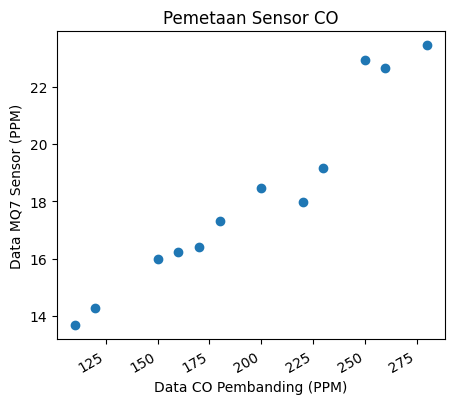

In [15]:
x = dfPolusi['CO'].iloc[0:12]
y = dfPolusi['MQ7'].iloc[0:12]

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data CO Pembanding (PPM)")
plt.ylabel("Data MQ7 Sensor (PPM)")
plt.title("Pemetaan Sensor CO")
plt.show()

Pesamaan Regresi:  16.181532736689668*X + -100.44510602599658


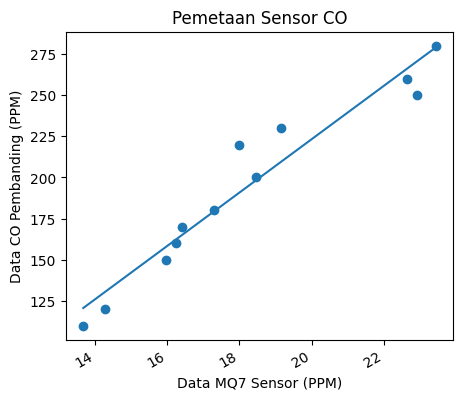

In [9]:
y = dfPolusi['CO'].iloc[0:12]
x = dfPolusi['MQ7'].iloc[0:12]

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data CO Pembanding (PPM)")
plt.xlabel("Data MQ7 Sensor (PPM)")
plt.title("Pemetaan Sensor CO")
plt.plot(x, mymodel)
plt.show()

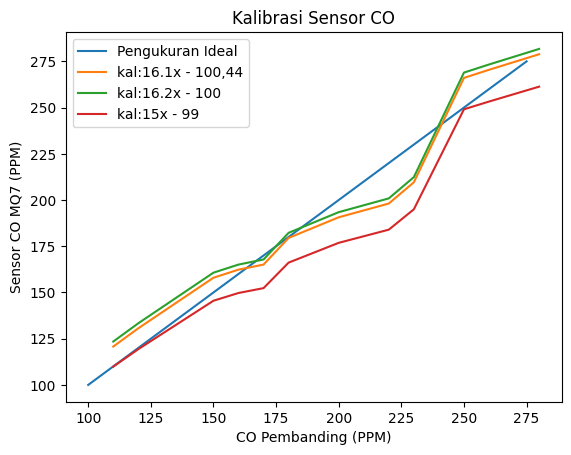

In [10]:
dtPengukuranCO = dfPolusi['CO'].iloc[0:12]
dtPengukuranCO = np.sort(dtPengukuranCO)
x = dfPolusi['MQ7'].iloc[0:12]
x = np.sort(x)

xIdeal = np.arange(100, 280, 5)
yIdeal = np.arange(100,280,5)
plt.plot(xIdeal,yIdeal)

kal = 16.181532736689668*x + -100.44510602599658
plt.plot(dtPengukuranCO,kal)

kal = 16.2*x + -98
plt.plot(dtPengukuranCO,kal)

kal = 15.5*x + -102
plt.plot(dtPengukuranCO,kal)

plt.xlabel("CO Pembanding (PPM)")
plt.ylabel("Sensor CO MQ7 (PPM)")
plt.title("Kalibrasi Sensor CO")
plt.legend(["Pengukuran Ideal", "kal:16.1x - 100,44", "kal:16.2x - 100", "kal:15x - 99"])
plt.show() 

    MQ135  CO2
0     386  785
1     385  761
2     380  714
3     379  690
4     376  673
5     373  645
6     369  611
7     365  609
8     358  569
9     353  566
10    337  531
11    329  512
12    309  511
13    307  498
14    282  494
15    272  455
16    247  402


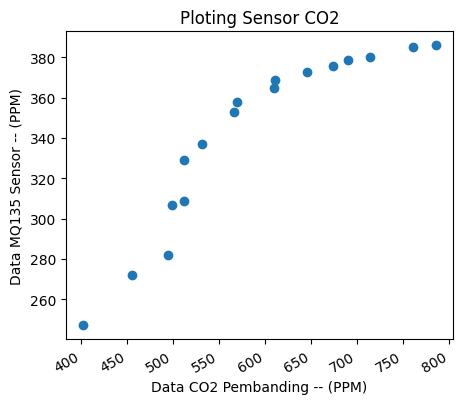

In [17]:
dataPolusi = df1
dataPolusi.to_csv('sensor_polusi_udara_CO2_13.csv', index=None, header=True)
dfPolusi = pd.DataFrame(pd.read_csv('sensor_polusi_udara_CO2_13.csv'))
print(dfPolusi)

x = dfPolusi['CO2']
y = dfPolusi['MQ135']

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data CO2 Pembanding -- (PPM)")
plt.ylabel("Data MQ135 Sensor -- (PPM)")
plt.title("Ploting Sensor CO2")
plt.show()

    MQ135  CO2
0     386  785
1     385  761
2     380  714
3     379  690
4     376  673
5     373  645
6     369  611
7     365  609
8     358  569
9     353  566
10    337  531
11    329  512
12    309  511
13    307  498
14    282  494
15    272  455
16    247  402
Pesamaan Regresi:  2.2870337023827503*X + -191.45910057274295


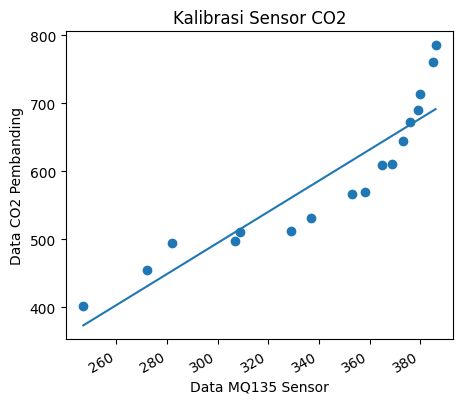

In [11]:
dataPolusi = df1
dataPolusi.to_csv('sensor_polusi_udara_CO2_13.csv', index=None, header=True)
dfPolusi = pd.DataFrame(pd.read_csv('sensor_polusi_udara_CO2_13.csv'))
print(dfPolusi)

y = dfPolusi['CO2']
x = dfPolusi['MQ135']

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data CO2 Pembanding")
plt.xlabel("Data MQ135 Sensor")
plt.title("Kalibrasi Sensor CO2")
plt.plot(x, mymodel)
plt.show()

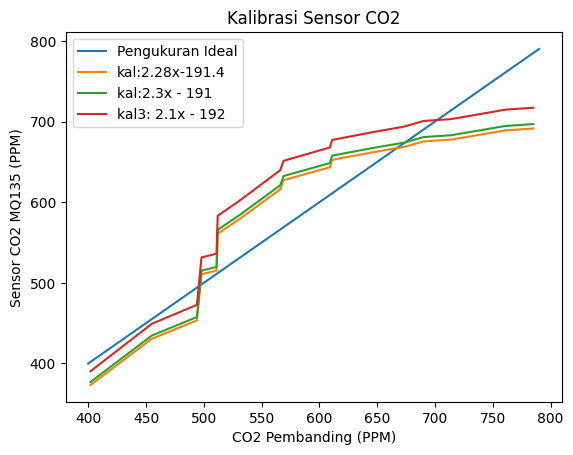

In [12]:
dtPengukuranCO2 = dfPolusi['CO2']
dtPengukuranCO2 = np.sort(dtPengukuranCO2)
x = dfPolusi['MQ135']
x = np.sort(x)

xIdeal = np.arange(400, 800, 10)
yIdeal = np.arange(400,800,10)
plt.plot(xIdeal,yIdeal)

kal = 2.2870337023827503*x + -191.45910057274295
plt.plot(dtPengukuranCO2,kal)

kal2 = 2.3*x + -191
plt.plot(dtPengukuranCO2,kal2)

kal3 = 2.35*x + -190
plt.plot(dtPengukuranCO2,kal3)

plt.xlabel("CO2 Pembanding (PPM)")
plt.ylabel("Sensor CO2 MQ135 (PPM)")
plt.title("Kalibrasi Sensor CO2")
plt.legend(["Pengukuran Ideal", "kal:2.28x-191.4", "kal:2.3x - 191", "kal3: 2.1x - 192"])
plt.show() 

# Data Sensor Kecepatan Angin

In [5]:
dataAngin = pd.read_excel('Sensor_Angin_New.xlsx')
dataAngin.to_csv('sensorAnginNEW.csv', index=None, header=True)
dfAngin = pd.DataFrame(pd.read_csv('sensorAnginNEW.csv'))
print(dfAngin)

    Unnamed: 0  anemo    sensor  Analog
0          NaN   18.8  47,62m/s     812
1          NaN   16.8  36,15m/s     615
2          NaN   15.8  29,62m/s     510
3          NaN   14.4  20,41m/s     465
4          NaN   14.2  26,20m/s     460
5          NaN   12.4   24,3m/s     420
6          NaN   11.2  16,31m/s     338
7          NaN    9.8  15,25m/s     266
8          NaN    8.7  10,38m/s     176
9          NaN    7.0   6,95m/s     107
10         NaN    6.5    5,4m/s      50
11         NaN    5.2   5,10m/s      46
12         NaN    3.5   1,06m/s      16


C:\Users\sugen\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\internals\blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


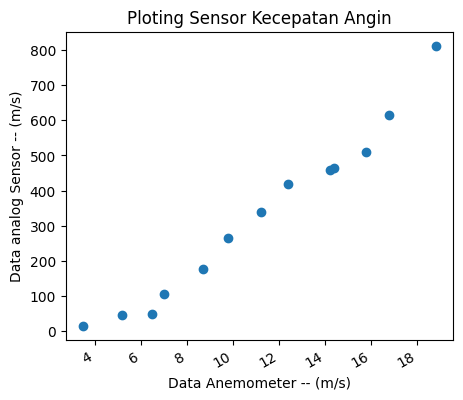

In [6]:
x = dfAngin['anemo']
y = dfAngin['Analog']


fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data Anemometer -- (m/s)")
plt.ylabel("Data analog Sensor -- (m/s)")
plt.title("Ploting Sensor Kecepatan Angin")
plt.show()

Pesamaan Regresi:  0.01913973760825831*X + 4.7971371768497075


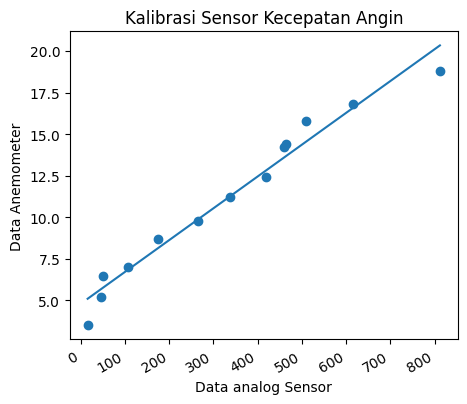

In [7]:
y = dfAngin['anemo']
x = dfAngin['Analog']

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data Anemometer")
plt.xlabel("Data analog Sensor")
plt.title("Kalibrasi Sensor Kecepatan Angin")
plt.plot(x, mymodel)
plt.show()

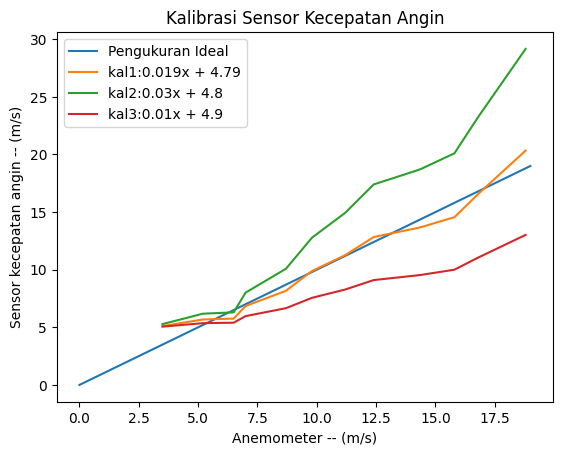

In [8]:
dtAnemometer = dfAngin['anemo']
x = dfAngin['Analog']

xIdeal = np.arange(0, 20, 1)
yIdeal = np.arange(0, 20, 1)
plt.plot(xIdeal,yIdeal)

kal =  0.019132559499197344*x + 4.799500983379707
plt.plot(dtAnemometer,kal)

kal2 =  0.03*x + 4.8
plt.plot(dtAnemometer,kal2)

kal3 =  0.01*x + 4.9
plt.plot(dtAnemometer,kal3)

plt.xlabel("Anemometer -- (m/s)")
plt.ylabel("Sensor kecepatan angin -- (m/s)")
plt.title("Kalibrasi Sensor Kecepatan Angin")
plt.legend(["Pengukuran Ideal", "kal1:0.019x + 4.79", "kal2:0.03x + 4.8", "kal3:0.01x + 4.9" ])
plt.show() 

In [9]:
x = dfAngin['anemo']
print(kal)
print(x)
dataSensor = np.array(x)
sensorPembanding = np.array(kal)

# Menghitung nilai error absolut
absolute_error = np.abs(dataSensor - sensorPembanding)

# Menghitung Mean Absolute Error (MAE)
mae = np.mean(absolute_error)

print("Mean Absolute Error (MAE):", mae)

0     20.335139
1     16.566025
2     14.557106
3     13.696141
4     13.600478
5     12.835176
6     11.266306
7      9.888762
8      8.166831
9      6.846685
10     5.756129
11     5.679599
12     5.105622
Name: Analog, dtype: float64
0     18.8
1     16.8
2     15.8
3     14.4
4     14.2
5     12.4
6     11.2
7      9.8
8      8.7
9      7.0
10     6.5
11     5.2
12     3.5
Name: anemo, dtype: float64
Mean Absolute Error (MAE): 0.64778520457766


# Sensor SO2-MQ136

In [8]:
dataSO2 = pd.read_excel('SensorGAS_SO2_PM25.xlsx', sheet_name='Sheet3')
dataSO2.to_csv('SensorGAS_SO2.csv', index=None, header=True)
dfSO2 = pd.DataFrame(pd.read_csv('SensorGAS_SO2.csv'))
print(dfSO2)

    MQ-136  Meter Gas
0       98        0.9
1      107        1.0
2      114        1.1
3      115        1.2
4      117        1.3
5      120        1.6
6      135        1.7
7      159        1.8
8      162        1.9
9      175        2.0
10     181        2.1
11     193        2.2
12     201        2.3
13     218        2.4
14     226        2.5
15     234        2.6
16     249        2.8
17     252        3.0
18     258        3.2
19     264        3.3
20     271        3.4
21     279        3.5
22     284        3.8
23     289        3.9
24     295        4.0
25     299        4.2
26     307        4.3
27     311        4.4
28     318        4.5
29     324        4.7
30     329        4.8
31     335        5.0
32     341        5.8
33     347        6.1
34     354        6.4
35     365        7.0
36     371        7.5
37     389        8.0


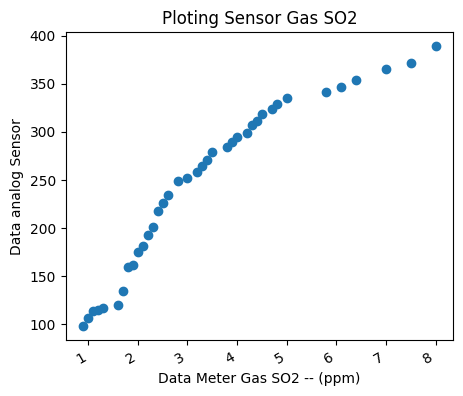

In [12]:
x = dfSO2['Meter Gas']
y = dfSO2['MQ-136']


fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data Meter Gas SO2 -- (ppm)")
plt.ylabel("Data analog Sensor")
plt.title("Ploting Sensor Gas SO2")
plt.show()

Pesamaan Regresi:  0.020548415792176235*X + -1.5965113322464775


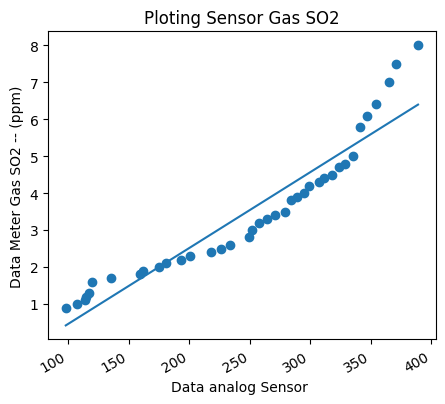

In [15]:
y = dfSO2['Meter Gas']
x = dfSO2['MQ-136']

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data Meter Gas SO2 -- (ppm)")
plt.xlabel("Data analog Sensor ")
plt.title("Ploting Sensor Gas SO2")
plt.plot(x,mymodel)
plt.show()

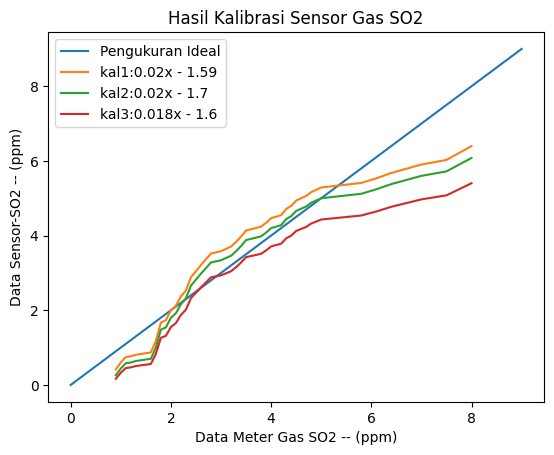

In [25]:
MeterGas = dfSO2['Meter Gas']
y = dfSO2['MQ-136']
x = y
xIdeal = np.arange(0, 10, 1)
yIdeal = np.arange(0, 10, 1)
plt.plot(xIdeal,yIdeal)

kal =  0.020548415792176235*x + -1.5965113322464775
plt.plot(MeterGas,kal)

kal2 =  0.02*x + -1.7
plt.plot(MeterGas,kal2)

kal3 =  0.018*x + -1.6
plt.plot(MeterGas,kal3)

plt.xlabel("Data Meter Gas SO2 -- (ppm)")
plt.ylabel("Data Sensor-SO2 -- (ppm)")
plt.title("Hasil Kalibrasi Sensor Gas SO2")
plt.legend(["Pengukuran Ideal", "kal1:0.02x - 1.59", "kal2:0.02x - 1.7", "kal3:0.018x - 1.6" ])
plt.show()

# Data Sensor PM2.5

In [29]:
dataPM = pd.read_excel('SensorGAS_SO2_PM25.xlsx', sheet_name='Sheet2')
dataPM.to_csv('SensorGAS_PM.csv', index=None, header=True)
dfPM = pd.DataFrame(pd.read_csv('SensorGAS_PM.csv'))
print(dfPM)

    Sensor Pm 2.5  Sensor Pm 10  Meter Pm 2.5 ug/m  Meter Pm 10 ug/m
0              22            23                 11                13
1              48            58                 56                74
2              52            63                 69                92
3              60            69                 81               102
4              69            75                 87               116
5              72            78                 91               121
6              76            85                103               135
7              88            90                110               143
8              90            95                120               146
9             107           110                139               186
10            110           110                140               183
11            115           116                149               191
12            117           119                159               198
13            119           122   

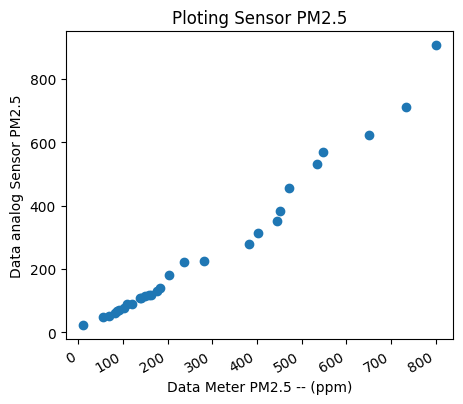

In [30]:
x = dfPM['Meter Pm 2.5 ug/m']
y = dfPM['Sensor Pm 2.5']


fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data Meter PM2.5 -- (ppm)")
plt.ylabel("Data analog Sensor PM2.5")
plt.title("Ploting Sensor PM2.5")
plt.show()

Pesamaan Regresi:  0.943432640960227*X + 42.16928124161018


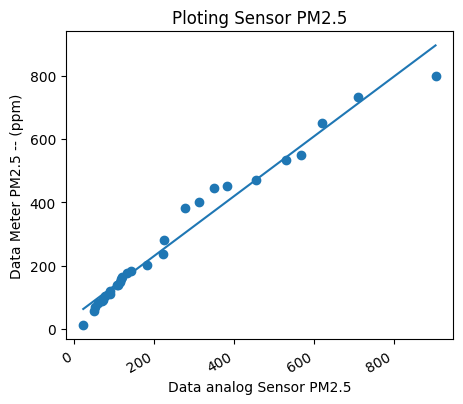

In [31]:
y = dfPM['Meter Pm 2.5 ug/m']
x = dfPM['Sensor Pm 2.5']

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data Meter PM2.5 -- (ppm)")
plt.xlabel("Data analog Sensor PM2.5")
plt.title("Ploting Sensor PM2.5")
plt.plot(x,mymodel)
plt.show()

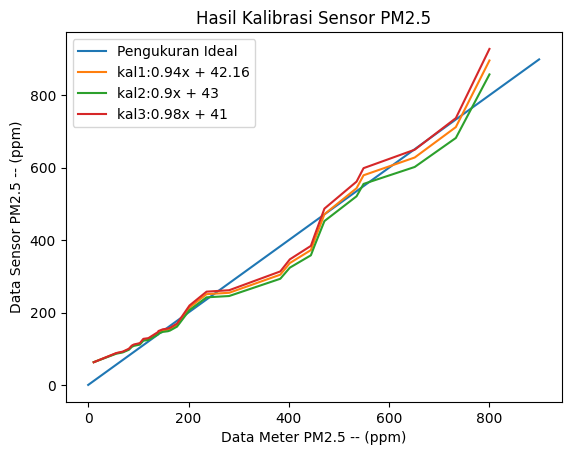

In [36]:
MeterPM25 = dfPM['Meter Pm 2.5 ug/m']
y = dfPM['Sensor Pm 2.5']
x = y

xIdeal = np.arange(0, 900, 1)
yIdeal = np.arange(0, 900, 1)
plt.plot(xIdeal,yIdeal)

kal =  0.943432640960227*x + 42.16928124161018
plt.plot(MeterPM25,kal)

kal2 =  0.9*x + 43
plt.plot(MeterPM25,kal2)

kal3 =  0.98*x + 41
plt.plot(MeterPM25,kal3)

plt.xlabel("Data Meter PM2.5 -- (ppm)")
plt.ylabel("Data Sensor PM2.5 -- (ppm)")
plt.title("Hasil Kalibrasi Sensor PM2.5")
plt.legend(["Pengukuran Ideal", "kal1:0.94x + 42.16", "kal2:0.9x + 43", "kal3:0.98x + 41" ])
plt.show()

# Data Sensor PM 10

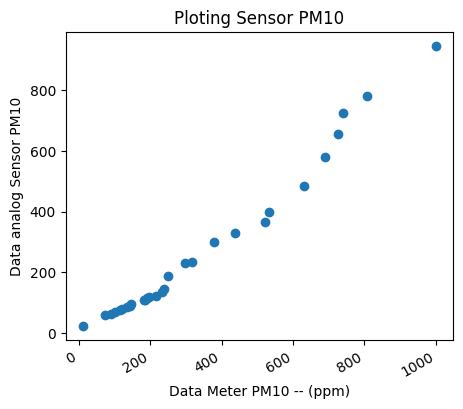

In [37]:
x = dfPM['Meter Pm 10 ug/m']
y = dfPM['Sensor Pm 10']


fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.xlabel("Data Meter PM10 -- (ppm)")
plt.ylabel("Data analog Sensor PM10")
plt.title("Ploting Sensor PM10")
plt.show()

Pesamaan Regresi:  1.02437715199609*X + 62.7982643695907


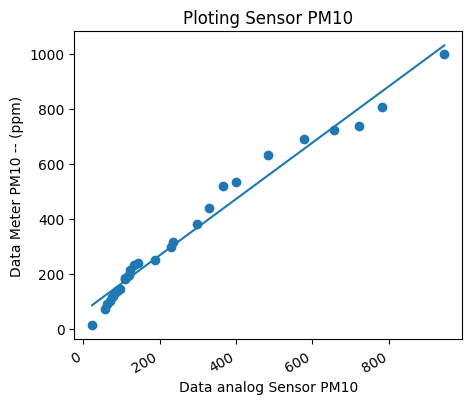

In [38]:
y = dfPM['Meter Pm 10 ug/m']
x = dfPM['Sensor Pm 10']

slope, intercept, r, p, std_err = stats.linregress(x, y)
print("Pesamaan Regresi: ", str(slope) + '*' + 'X' + ' + ' + str(intercept))

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

fig = plt.subplots(figsize=(5, 4))
plt.xticks(rotation=30, ha='right')
plt.scatter(x, y)
plt.ylabel("Data Meter PM10 -- (ppm)")
plt.xlabel("Data analog Sensor PM10")
plt.title("Ploting Sensor PM10")
plt.plot(x,mymodel)
plt.show()

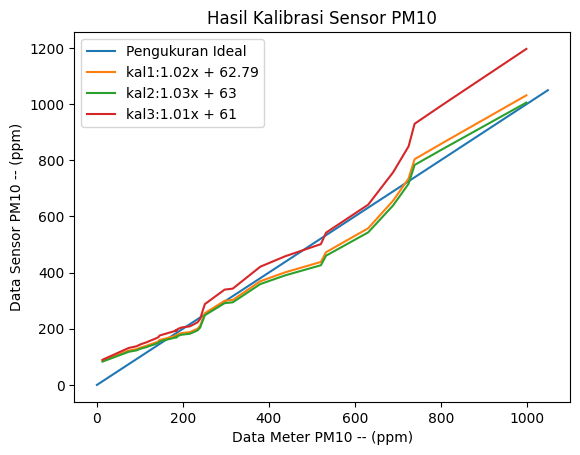

In [47]:
MeterPM10 = dfPM['Meter Pm 10 ug/m']
y = dfPM['Sensor Pm 10']
x = y

xIdeal = np.arange(0, 1050, 1)
yIdeal = np.arange(0, 1050, 1)
plt.plot(xIdeal,yIdeal)

kal =  1.02437715199609*x + 62.7982643695907
plt.plot(MeterPM10,kal)

kal2 =  1.0*x + 60
plt.plot(MeterPM10,kal2)

kal3 =  1.2*x + 62
plt.plot(MeterPM10,kal3)

plt.xlabel("Data Meter PM10 -- (ppm)")
plt.ylabel("Data Sensor PM10 -- (ppm)")
plt.title("Hasil Kalibrasi Sensor PM10")
plt.legend(["Pengukuran Ideal", "kal1:1.02x + 62.79", "kal2:1.03x + 63", "kal3:1.01x + 61" ])
plt.show()